In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.cosmology import FlatLambdaCDM as cosmo
from astropy import units as u
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from scipy.interpolate import interp1d

In [ ]:
mpc_to_cm = 3.08567758e24
z=3.63963
cosmo_model = cosmo(H0=70, Om0=0.3)
d_mpc = cosmo_model.luminosity_distance(z).value
d_mpc

np.float64(32043.997988284074)

/tmp/ipykernel_21591/3914350828.py:23: RuntimeWarning: divide by zero encountered in divide
  plt.fill_between(wavelength, flux - 1/np.sqrt(data['ivar']), flux + 1/np.sqrt(data['ivar']), color='hotpink', alpha=1, label='Flux Uncertainty')


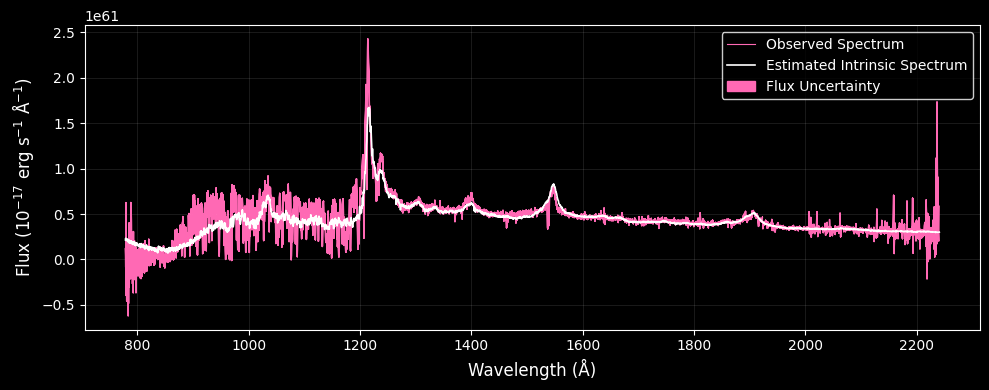

In [ ]:
hdul = fits.open('spec.fits')
data = hdul[1].data

wavelength = 10**data['loglam']
flux = data['flux']
fit=data['model']

#shift to rest frame when z=3.63963

wavelength = wavelength/(1+z)
flux=flux*(1+z)*4*np.pi*(d_mpc*mpc_to_cm)**2
fit=fit*(1+z)*4*np.pi*(d_mpc*mpc_to_cm)**2

plt.style.use('dark_background')

plt.figure(figsize=(10, 4))

plt.plot(wavelength, flux, lw=0.8, color='hotpink', label='Observed Spectrum')
plt.plot(wavelength, fit, lw=1.2, color='white', label='Estimated Intrinsic Spectrum')

plt.xlabel('Restframe Wavelength (Å)', fontsize=12, color='white')
plt.xlabel('Wavelength (Å)', fontsize=12, color='white')
plt.fill_between(wavelength, flux - 1/np.sqrt(data['ivar']), flux + 1/np.sqrt(data['ivar']), color='hotpink', alpha=1, label='Flux Uncertainty')
plt.ylabel(r'Flux ($10^{-17}\ \mathrm{erg\ s^{-1}\ \AA^{-1}}$)', fontsize=12, color='white')

plt.tick_params(axis='both', colors='white')
plt.grid(color='white', alpha=0.1)

plt.legend(fontsize=10, facecolor='black', edgecolor='white')

plt.tight_layout()
plt.show()

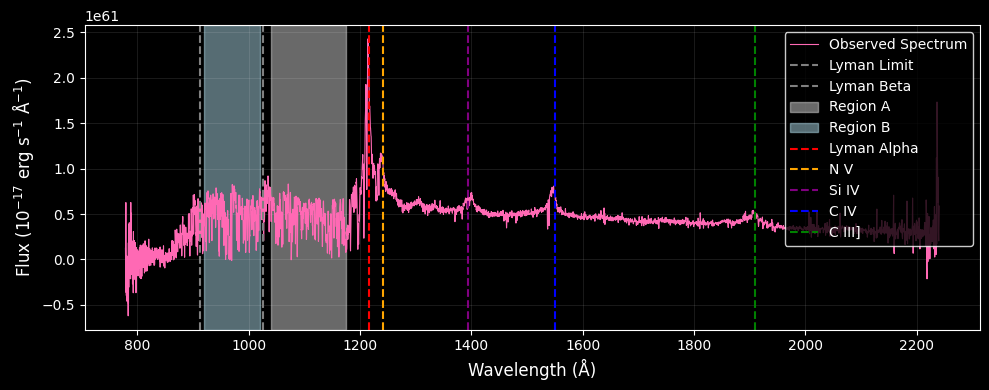

In [ ]:
plt.style.use('dark_background')

plt.figure(figsize=(10, 4))

plt.plot(wavelength, flux, lw=0.8, color='hotpink', label='Observed Spectrum')

plt.xlabel('Restframe Wavelength (Å)', fontsize=12, color='white')
plt.xlabel('Wavelength (Å)', fontsize=12, color='white')

plt.ylabel(r'Flux ($10^{-17}\ \mathrm{erg\ s^{-1}\ \AA^{-1}}$)', fontsize=12, color='white')

plt.tick_params(axis='both', colors='white')
plt.grid(color='white', alpha=0.1)


plt.axvline(x=912, color='gray', linestyle='--', label='Lyman Limit')
plt.axvline(x=1025.72, color='gray', linestyle='--', label='Lyman Beta')
plt.axvspan(1040, 1175, color='lightgray', alpha=0.5, label='Region A')
plt.axvspan(920, 1020, color='lightblue', alpha=0.5, label='Region B')

plt.axvline(x=1215.67, color='red', linestyle='--', label='Lyman Alpha')
plt.axvline(x=1240.81, color='orange', linestyle='--', label='N V')
plt.axvline(x=1393.76, color='purple', linestyle='--', label='Si IV')
plt.axvline(x=1549.48, color='blue', linestyle='--', label='C IV')
plt.axvline(x=1908.73, color='green', linestyle='--', label='C III]')


plt.legend(fontsize=10, facecolor='black', edgecolor='white')

plt.tight_layout()
plt.show()

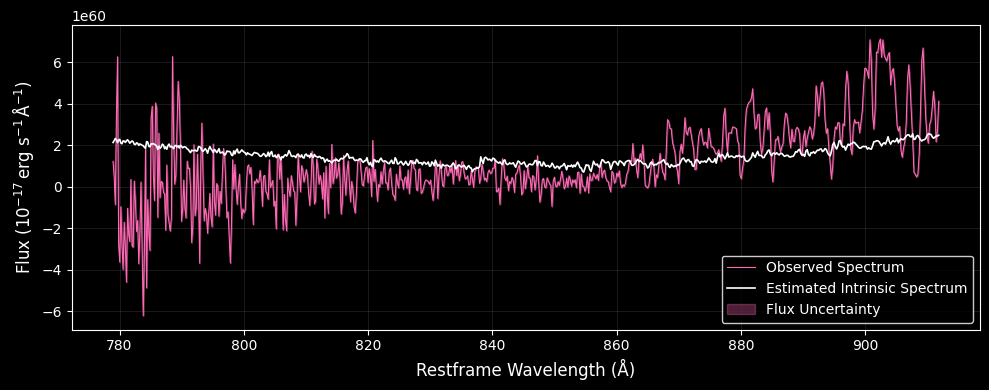

In [ ]:
mask_912_left = (wavelength < 912)

wavelength_912_left = wavelength[mask_912_left]
flux_912_left = flux[mask_912_left]
fit_912_left = fit[mask_912_left]

plt.style.use('dark_background')
plt.figure(figsize=(10, 4))

plt.plot(wavelength_912_left, flux_912_left, lw=0.8, color='hotpink', label='Observed Spectrum')
plt.plot(wavelength_912_left, fit_912_left, lw=1.2, color='white', label='Estimated Intrinsic Spectrum')


ivar_912_left = data['ivar'][mask_912_left]
valid_ivar_mask = (ivar_912_left > 0) & np.isfinite(ivar_912_left)

if np.any(valid_ivar_mask):
    plt.fill_between(
        wavelength_912_left[valid_ivar_mask],
        flux_912_left[valid_ivar_mask] - 1 / np.sqrt(ivar_912_left[valid_ivar_mask]),
        flux_912_left[valid_ivar_mask] + 1 / np.sqrt(ivar_912_left[valid_ivar_mask]),
        color='hotpink', alpha=0.3, label='Flux Uncertainty'
    )

plt.xlabel('Restframe Wavelength (Å)', fontsize=12, color='white')
plt.ylabel(r'Flux ($10^{-17}\,\mathrm{erg\ s^{-1}\,\AA^{-1}}$)', fontsize=12, color='white')

plt.tick_params(axis='both', colors='white')
plt.grid(color='white', alpha=0.1)

plt.legend(fontsize=10, facecolor='black', edgecolor='white')

plt.tight_layout()
plt.show()

In [ ]:
#fit continuum power law on 1300-2000 angstrom

mask = (wavelength > 1300) & (wavelength < 2000)
wavelength_fit = wavelength[mask]
flux_fit = fit[mask]

emission_lines = [1549, 1397, 1909]
line_mask = np.ones_like(wavelength_fit, dtype=bool)
for line in emission_lines:
    line_mask &= (wavelength_fit < line - 20) | (wavelength_fit > line + 20)
wavelength_fit = wavelength_fit[line_mask]
flux_fit = flux_fit[line_mask]

log_wavelength_fit = np.log10(wavelength_fit)
log_flux_fit = np.log10(flux_fit)
coefficients = np.polyfit(log_wavelength_fit, log_flux_fit, 1)
power_law_fit = np.poly1d(coefficients)
continuum_fit = power_law_fit(log_wavelength_fit)


wavelength_fit = 10**log_wavelength_fit
continuum_fit = 10**continuum_fit

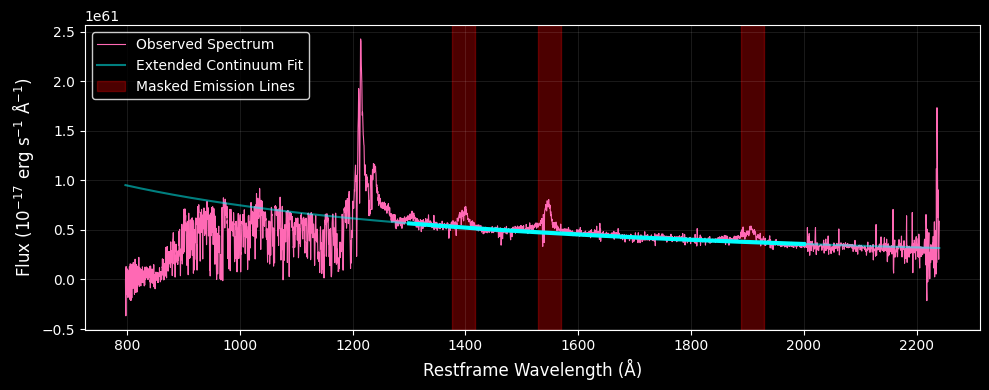

In [ ]:
plt.style.use('dark_background')
plt.figure(figsize=(10, 4))


wavelength = wavelength[100:]
flux = flux[100:]

plt.plot(wavelength, flux, lw=0.8, color='hotpink', label
='Observed Spectrum')
plt.plot(wavelength_fit, continuum_fit, lw=3, color='cyan')
continuum_fit_full = power_law_fit(np.log10(wavelength))
continuum_fit_full = 10**continuum_fit_full
plt.plot(wavelength, continuum_fit_full, lw=1.5, color='cyan', alpha=0.5, label='Extended Continuum Fit')
for line in emission_lines:
    plt.axvspan(line - 20, line + 20, color='red', alpha=0.3, label='Masked Emission Lines' if line == emission_lines[0] else "")
plt.xlabel('Restframe Wavelength (Å)', fontsize=12, color='white')
plt.ylabel(r'Flux ($10^{-17}\ \mathrm{erg\ s^{-1}\ \AA^{-1}}$)', fontsize=12, color='white')
plt.tick_params(axis='both', colors='white')
plt.grid(color='white', alpha=0.1)
plt.legend(fontsize=10, facecolor='black', edgecolor='white')
plt.tight_layout()
plt.show()

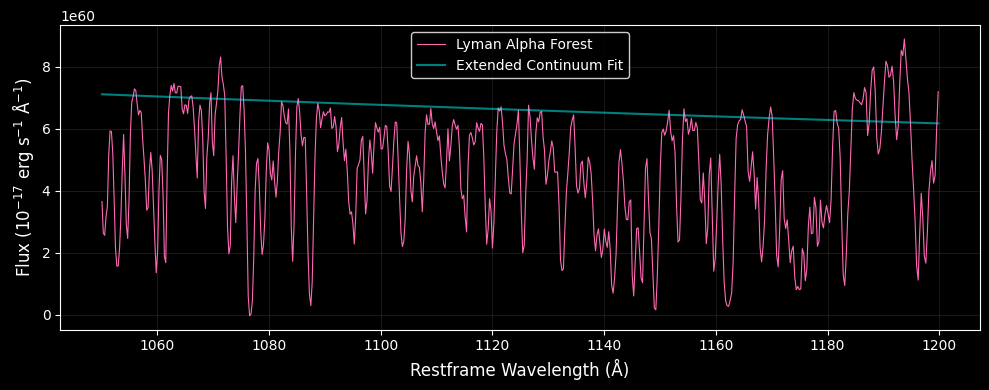

In [ ]:
mask_lyman_alpha = (wavelength > 1050) & (wavelength < 1200)
wavelength_lyman_alpha = wavelength[mask_lyman_alpha]
flux_lyman_alpha = flux[mask_lyman_alpha]
plt.style.use('dark_background')
plt.figure(figsize=(10, 4))
plt.plot(wavelength_lyman_alpha, flux_lyman_alpha, lw=0.8, color='hotpink', label='Lyman Alpha Forest')
plt.plot(wavelength_lyman_alpha, continuum_fit_full[mask_lyman_alpha], lw=1.5, color='cyan', alpha=0.5, label='Extended Continuum Fit')
plt.xlabel('Restframe Wavelength (Å)', fontsize=12, color='white')
plt.ylabel(r'Flux ($10^{-17}\ \mathrm{erg\ s^{-1}\ \AA^{-1}}$)', fontsize=12, color='white')
plt.tick_params(axis='both', colors='white')
plt.grid(color='white', alpha=0.1)
plt.legend(fontsize=10, facecolor='black', edgecolor='white')
plt.tight_layout()
plt.show()

In [ ]:
tau = -np.log(flux_lyman_alpha / continuum_fit_full[mask_lyman_alpha])
tau = interp1d(wavelength_lyman_alpha[~np.isnan(tau)], tau[~np.isnan(tau)], bounds_error=False, fill_value='extrapolate')(wavelength_lyman_alpha)

tau_smooth = gaussian_filter1d(tau, sigma=1)

c = 3e8
frequencies = c / (wavelength_lyman_alpha * 1e-10)

/tmp/ipykernel_21591/903596587.py:1: RuntimeWarning: invalid value encountered in log
  tau = -np.log(flux_lyman_alpha / continuum_fit_full[mask_lyman_alpha])


In [ ]:
def gaussian(x, A, x0, sigma):
    return A * np.exp(-(x - x0)**2 / (2 * sigma**2))

lyman_alpha_rest_wavelength_angstrom = 1215.67
peaks, _ = find_peaks(tau_smooth, height=0.5)

line_fits_restframe = []

for peak_idx in peaks:
    # 1. Determine the observed wavelength and redshift of this peak
    observed_wavelength_dip_angstrom = wavelength_lyman_alpha[peak_idx]
    z_dip = (observed_wavelength_dip_angstrom / lyman_alpha_rest_wavelength_angstrom) - 1

    # 2. Extract a window around the peak in the *quasar restframe*
    window_half_points = 10
    start_idx = max(0, peak_idx - window_half_points)
    end_idx = min(len(wavelength_lyman_alpha), peak_idx + window_half_points + 1)

    segment_wavelength_obs = wavelength_lyman_alpha[start_idx:end_idx]
    segment_flux_obs = flux_lyman_alpha[start_idx:end_idx]
    segment_continuum_obs = continuum_fit_full[mask_lyman_alpha][start_idx:end_idx]

    if len(segment_wavelength_obs) < 3: # Need enough points for fitting
        continue

    # 3. Shift the segment data to the *absorption line's own rest frame*
    segment_wavelength_rest = segment_wavelength_obs / (1 + z_dip)
    segment_flux_rest = segment_flux_obs / (1 + z_dip) # Flux scaling for intensity
    segment_continuum_rest = segment_continuum_obs / (1 + z_dip) # Continuum scaling

    # 4. Calculate optical depth in the *absorption line's rest frame*
    # Handle potential RuntimeWarning for invalid log, and then interpolate
    with np.errstate(divide='ignore', invalid='ignore'):
        tau_segment_rest_raw = -np.log(segment_flux_rest / segment_continuum_rest)

    # Interpolate NaN values, if any, similar to how global tau is handled
    # This can be tricky if there are many NaNs or very short segments
    valid_tau_mask = ~np.isnan(tau_segment_rest_raw)
    if np.sum(valid_tau_mask) < 3: # Need at least 3 valid points for interp1d and curve_fit
        continue

    # Ensure interpolation is done on valid parts and then applied to the full segment range
    if np.any(valid_tau_mask):
        interp_func = interp1d(segment_wavelength_rest[valid_tau_mask],
                               tau_segment_rest_raw[valid_tau_mask],
                               bounds_error=False, fill_value='extrapolate')
        tau_segment_rest = interp_func(segment_wavelength_rest)
    else:
        continue # No valid tau points in segment

    # 5. Smooth the rest-frame optical depth
    tau_smooth_segment_rest = gaussian_filter1d(tau_segment_rest, sigma=1)

    # 6. Convert rest-frame wavelength to rest-frame frequency for fitting
    frequencies_segment_rest = c / (segment_wavelength_rest * 1e-10) # Frequencies in Hz

    # 7. Perform Gaussian fitting on the rest-frame optical depth in frequency space
    A_guess = np.max(tau_smooth_segment_rest) # Amplitude guess from smoothed data
    x0_guess = frequencies_segment_rest[np.argmax(tau_smooth_segment_rest)] # Frequency of max tau
    sigma_guess = 5e11 # Initial width guess

    if A_guess <= 0: # Ensure positive amplitude for fitting
        continue

    # Bounds for curve_fit
    bounds_lower = [0.01, frequencies_segment_rest.min(), 1e9]
    bounds_upper = [A_guess * 5, frequencies_segment_rest.max(), 5e13]

    try:
        popt, pcov = curve_fit(gaussian, frequencies_segment_rest, tau_smooth_segment_rest,
                               p0=[A_guess, x0_guess, sigma_guess],
                               bounds=(bounds_lower, bounds_upper))

        A_fit, x0_fit, sigma_fit = popt

        # Add checks for fit quality
        if A_fit > 0.1 and sigma_fit > 1e10 and sigma_fit < 5e12 and \
           (x0_fit >= frequencies_segment_rest.min() and x0_fit <= frequencies_segment_rest.max()):
            line_fits_restframe.append(popt)
    except (RuntimeError, ValueError):
        pass # Skip if fitting fails for a segment

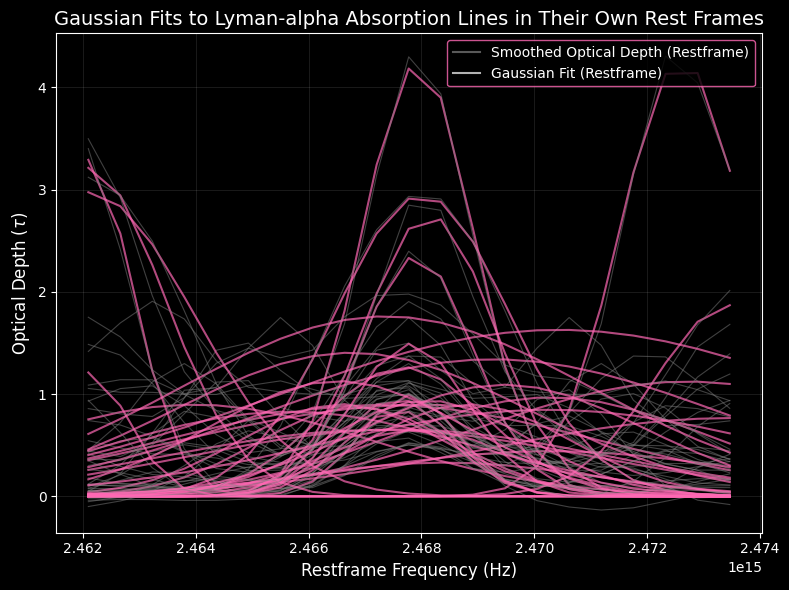

Fitted Gaussian parameters (A, x0_freq_restframe, sigma_freq_restframe) for each absorption line in its own restframe:
  A=8.96e-01, x0_freq=2.47e+15 Hz, sigma_freq=4.34e+12 Hz
  A=1.12e+00, x0_freq=2.47e+15 Hz, sigma_freq=3.64e+12 Hz
  A=8.97e-01, x0_freq=2.46e+15 Hz, sigma_freq=3.17e+12 Hz
  A=8.95e-01, x0_freq=2.47e+15 Hz, sigma_freq=3.90e+12 Hz
  A=9.68e-01, x0_freq=2.47e+15 Hz, sigma_freq=2.83e+12 Hz
  A=3.30e-01, x0_freq=2.47e+15 Hz, sigma_freq=2.59e+12 Hz
  A=8.75e-01, x0_freq=2.47e+15 Hz, sigma_freq=1.73e+12 Hz
  A=3.29e+00, x0_freq=2.46e+15 Hz, sigma_freq=8.07e+11 Hz
  A=4.24e+00, x0_freq=2.47e+15 Hz, sigma_freq=9.96e+11 Hz
  A=4.27e+00, x0_freq=2.47e+15 Hz, sigma_freq=1.11e+12 Hz
  A=7.66e-01, x0_freq=2.47e+15 Hz, sigma_freq=4.30e+12 Hz
  A=9.94e-01, x0_freq=2.47e+15 Hz, sigma_freq=8.75e+11 Hz
  A=2.35e+00, x0_freq=2.47e+15 Hz, sigma_freq=1.02e+12 Hz
  A=6.55e-01, x0_freq=2.47e+15 Hz, sigma_freq=3.66e+12 Hz
  A=6.50e-01, x0_freq=2.47e+15 Hz, sigma_freq=3.77e+12 Hz
  A=4.42e-0

In [ ]:
plt.style.use('dark_background')
plt.figure(figsize=(8, 6))
z_dips=[]
segment_fluxes_rest=[]
segment_continua_rest=[]

# Plot each fitted Gaussian on its corresponding rest-frame optical depth segment
for i, fit_params in enumerate(line_fits_restframe):

    peak_idx = peaks[i] # This assumes line_fits_restframe has same order as peaks

    observed_wavelength_dip_angstrom = wavelength_lyman_alpha[peak_idx]
    z_dip = (observed_wavelength_dip_angstrom / lyman_alpha_rest_wavelength_angstrom) - 1
    z_dips.append(z_dip)

    # Extract a window around the peak in the *quasar restframe*

    window_half_points = 10
    start_idx = max(0, peak_idx - window_half_points)
    end_idx = min(len(wavelength_lyman_alpha), peak_idx + window_half_points + 1)

    segment_wavelength_obs = wavelength_lyman_alpha[start_idx:end_idx]
    segment_flux_obs = flux_lyman_alpha[start_idx:end_idx]
    segment_continuum_obs = continuum_fit_full[mask_lyman_alpha][start_idx:end_idx]

    segment_wavelength_rest = segment_wavelength_obs / (1 + z_dip)
    segment_flux_rest = segment_flux_obs / (1 + z_dip)
    segment_continuum_rest = segment_continuum_obs / (1 + z_dip)

    idx_max = np.argmax(segment_flux_rest)

    segment_fluxes_rest.append(segment_flux_rest[idx_max])
    segment_continua_rest.append(segment_continuum_rest[idx_max])


    # Calculate optical depth in the *absorption line's rest frame*

    with np.errstate(divide='ignore', invalid='ignore'):
        tau_segment_rest_raw = -np.log(segment_flux_rest / segment_continuum_rest)
    valid_tau_mask = ~np.isnan(tau_segment_rest_raw)

    if np.any(valid_tau_mask):
        interp_func = interp1d(segment_wavelength_rest[valid_tau_mask],
                               tau_segment_rest_raw[valid_tau_mask],
                               bounds_error=False, fill_value='extrapolate')
        tau_segment_rest = interp_func(segment_wavelength_rest)
    else:
        continue

    tau_smooth_segment_rest = gaussian_filter1d(tau_segment_rest, sigma=1)
    frequencies_segment_rest = c / (segment_wavelength_rest * 1e-10)

    # Plot the smoothed rest-frame optical depth for this segment
    plt.plot(frequencies_segment_rest, tau_smooth_segment_rest, lw=0.8, color='gray', alpha=0.5)

    # Plot the fitted Gaussian curve over this segment
    A_fit, x0_fit, sigma_fit = fit_params

    plt.plot(frequencies_segment_rest, gaussian(frequencies_segment_rest, A_fit, x0_fit, sigma_fit),
             lw=1.5, color='hotpink', alpha=0.7)

# Create proxy artists for the legend
from matplotlib.lines import Line2D
custom_line_tau = Line2D([0], [0], color='gray', lw=1.5, alpha=0.7)
custom_line_fit = Line2D([0], [0], color='white', lw=1.5, alpha=0.7)
plt.legend(handles=[custom_line_tau, custom_line_fit],
           labels=['Smoothed Optical Depth (Restframe)', 'Gaussian Fit (Restframe)'],
           fontsize=10, facecolor='black', edgecolor='hotpink', loc='upper right')

plt.xlabel('Restframe Frequency (Hz)', fontsize=12, color='white')
plt.ylabel(r'Optical Depth ($\tau$)', fontsize=12, color='white')
plt.title('Gaussian Fits to Lyman-alpha Absorption Lines in Their Own Rest Frames', fontsize=14, color='white')
plt.tick_params(axis='both', colors='white')
plt.grid(color='white', alpha=0.1)
plt.tight_layout()
plt.show()

# Print the new list of rest-frame fits (optional, but useful for user)
print("Fitted Gaussian parameters (A, x0_freq_restframe, sigma_freq_restframe) for each absorption line in its own restframe:")
for fit in line_fits_restframe:
    print(f"  A={fit[0]:.2e}, x0_freq={fit[1]:.2e} Hz, sigma_freq={fit[2]:.2e} Hz")

In [ ]:
#calculate effective optical depth by using -ln(sumF_obs)/(sumF_model))
tau_eff = -np.log(np.sum(flux_lyman_alpha) / np.sum(continuum_fit_full[mask_lyman_alpha]))
print(f'Effective Optical Depth (τ_eff): {tau_eff:.2f}')

Effective Optical Depth (τ_eff): 0.36


In [ ]:
f=0.4162
sigma_0=2.65e-2
coeff=1.5e11
column_densities = np.array([amp/f/sigma_0*np.sqrt(2*np.pi)*coeff for amp, _, _ in line_fits_restframe])
column_densities

array([3.05294670e+13, 3.82833786e+13, 3.05850982e+13, 3.05056825e+13,
       3.30038925e+13, 1.12548452e+13, 2.98373734e+13, 1.12193340e+14,
       1.44506637e+14, 1.45708535e+14, 2.60962830e+13, 3.38731638e+13,
       8.01789297e+13, 2.23381124e+13, 2.21599214e+13, 1.50633232e+13,
       2.22366013e+13, 3.07572487e+13, 3.06899254e+13, 3.26113236e+13,
       4.30938292e+13, 4.57087628e+13, 6.37167847e+13, 4.78950609e+13,
       1.09526127e+14, 9.37941440e+13, 2.86108323e+13, 2.82398687e+13,
       1.01395734e+14, 1.00464341e+14, 3.19716004e+13, 6.00249744e+13,
       5.55197487e+13, 2.88887411e+13, 4.12996220e+13, 5.08981024e+13,
       3.84368564e+13, 3.72385084e+13])

In [ ]:
np.sum(column_densities/1e15)

np.float64(1.9291367201290195)

In [ ]:
mask_integration = (wavelength < 912) & (wavelength>820)

wavelength_new_range = wavelength[mask_integration]
continuum_new_range = continuum_fit_full[mask_integration]

h_cgs = 6.62607015e-27
c_cgs = 2.99792458e10

N_lambda_new = continuum_new_range * 1e-17*(wavelength_new_range * 1e-8) / (h_cgs * c_cgs)
q = np.trapezoid(y=N_lambda_new, x=wavelength_new_range)

print(f'Total photon flux (Lv/hv equivalent) for wavelength < 912 Å: {q:.2e} photons s^-1 ')

Total photon flux (Lv/hv equivalent) for wavelength < 912 Å: 3.49e+56 photons s^-1 


In [ ]:
r_mpc=cosmo_model.comoving_distance(z).value/(1+z)

In [ ]:
#u close to earth
z=3.63963
#absorber column density=2e15/cm2 with ionisation fraction 1e-5
#r_mpc = cosmo_model.comoving_distance(z).value/(1+z)
u=q/4/np.pi/(r_mpc*mpc_to_cm)/c_cgs/(1.92e20)
u

np.float64(0.0010509959062634958)

In [ ]:
#u near quasar proximity zone
#2 physical mpc
#absorber column density=1e20/cm2 with ionisation fraction 1e-6

u_qp=q/4/np.pi/(2*mpc_to_cm)/c_cgs/(1e26)
u_qp

np.float64(1.5019388715747701e-06)

In [ ]:
#0.0243 angstrom is the compton wavelength
compton_freq=3e8/0.0243e-10
compton_freq

1.2345679012345679e+20

In [ ]:
tau_thomson=1.92e20*6.65e-25
tau_thomson

0.00012768

In [ ]:
#will hard xray be in the klein nishina regime?

100/511

0.19569471624266144